In [377]:
from numpy import lib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import statsmodels.api as sm1
import talib
from hmmlearn.hmm import GaussianHMM
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [378]:
# Load data from file
file = "/Users/nathansebbag/Desktop/Imperial College/Cours/Systematic Trading with ML/Coursework/ohlcv_data.csv"
print(f"Loading data from file...")
data_df = pd.read_csv(file)

signal = "/Users/nathansebbag/Desktop/Imperial College/Cours/Systematic Trading with ML/Coursework/primary_signals.csv"
print(f"Loading primary sigal from file...")
signal_df = pd.read_csv(signal)

Loading data from file...
Loading primary sigal from file...


In [379]:
# Display basic information about the dataset
print(f"Dataset shape: {data_df.shape}")
print(f"First few columns: {data_df.columns}...")

Dataset shape: (83547, 8)
First few columns: Index(['date', 'instrument', 'open', 'high', 'low', 'close', 'volume',
       'open_interest'],
      dtype='object')...


In [380]:
commodities = ["cl1s", "ho1s", "rb1s", "ng1s"]
data_df[data_df['instrument'].isin(commodities)]
data_df.head()

,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.8000,22.920,21.7900,22.8900,22868.0,66308.0
1,1990-01-02,gc1s,401.0000,404.600,400.2000,402.1000,20747.0,68855.0
2,1990-01-02,hg1s,1.0470,1.064,1.0430,1.0620,3325.0,19735.0
3,1990-01-02,ho1s,0.7475,0.776,0.7415,0.7739,20280.0,33732.0
4,1990-01-02,pl1s,484.0000,485.000,479.5000,482.2000,4561.0,13256.0


In [381]:
# Seperate the df for each commodity 

# WTI Crude Oil df
WTI_df = data_df[data_df['instrument']=="cl1s"].set_index("date")

# Heating Oil df
Heating_oil_df = data_df[data_df['instrument']=="ho1s"].set_index("date")

# RBOB Gasoline df
RBOB_df = data_df[data_df['instrument']=="rb1s"].set_index("date")

# Natural Gas df
Nat_gas_df = data_df[data_df['instrument']=="ng1s"].set_index("date")


print(f"WTI Crude Oil \n {WTI_df.head()} \n\n nb de lignes : {len(WTI_df)}\n")
print(print(f"Date range: {WTI_df.index.min()} to {WTI_df.index.max()}\n"))
print("#"*50,"\n")
print(f"Heating oil\n {Heating_oil_df.head()} \n\n Nb de lignes: {len(Heating_oil_df)}")
print(print(f"Date range: {Heating_oil_df.index.min()} to {Heating_oil_df.index.max()}"))


WTI Crude Oil 
            instrument   open   high    low  close   volume  open_interest
date                                                                     
1990-01-02       cl1s  21.80  22.92  21.79  22.89  22868.0        66308.0
1990-01-03       cl1s  23.20  23.80  23.00  23.68  45177.0        61428.0
1990-01-04       cl1s  23.88  23.92  22.83  23.41  50061.0        60995.0
1990-01-05       cl1s  23.42  23.70  23.03  23.08  53070.0        57258.0
1990-01-08       cl1s  22.60  22.60  21.55  21.62  39720.0        54644.0 

 nb de lignes : 8171

Date range: 1990-01-02 to 2022-06-30

None
################################################## 

Heating oil
            instrument    open   high     low   close   volume  open_interest
date                                                                        
1990-01-02       ho1s  0.7475  0.776  0.7415  0.7739  20280.0        33732.0
1990-01-03       ho1s  0.7850  0.785  0.7560  0.7820  17564.0        33477.0
1990-01-04       ho1s  0.

In [382]:
print(f"RBOB Gasoline\n {RBOB_df.head()} \n\n Nb de lignes {len(RBOB_df)} \n")
print(print(f"Date range: {RBOB_df.index.min()} to {RBOB_df.index.max()}\n"))
print("#"*50,"\n")
print(f"Natural Gas {Nat_gas_df.head()} \n\n Nb de Lignes {len(Nat_gas_df)}")
print(print(f"Date range: {Nat_gas_df.index.min()} to {Nat_gas_df.index.max()}"))

RBOB Gasoline
            instrument    open    high     low   close   volume  open_interest
date                                                                         
1990-01-02       rb1s  0.6260  0.6580  0.6225  0.6569  13854.0        18623.0
1990-01-03       rb1s  0.6700  0.6770  0.6500  0.6723  12399.0        17273.0
1990-01-04       rb1s  0.6825  0.6825  0.6360  0.6529  12314.0        17711.0
1990-01-05       rb1s  0.6500  0.6530  0.6130  0.6222  10698.0        17047.0
1990-01-08       rb1s  0.5950  0.6190  0.5840  0.5848   8661.0        16230.0 

 Nb de lignes 8170 

Date range: 1990-01-02 to 2022-06-30

None
################################################## 

Natural Gas            instrument   open   high    low  close  volume  open_interest
date                                                                    
1990-04-04       ng1s  1.610  1.650  1.599  1.620   240.0          127.0
1990-04-05       ng1s  1.615  1.635  1.610  1.615     0.0          112.0
1990-04-06      

In [383]:
commo = {}
commo["WTI"] = WTI_df
commo["Heating_oil"] = Heating_oil_df
commo["RBOB"] = RBOB_df
commo["Nat_gas"] = Nat_gas_df

## Documentation des features

Notre feature set est organisé en 8 catégories, chacune capturant un aspect différent du marché :

### 1. Microstructure intraday (3 features)
- `hl_spread` : amplitude haut-bas relative → mesure de stress intraday
- `oc_spread` : variation open-close relative → directionnalité de la journée
- `close_position` : position du close dans la range → pression acheteuse/vendeuse

### 2. Multi-horizons returns / volatilité / momentum (16 features)
- `returns_{5,10,20,60}` : rendements log multi-horizons → capturer momentum à différentes échelles
- `vol_{5,10,20,60}` : écart-type rolling → régime de volatilité multi-échelles
- `mom_{5,10,20,60}` : momentum brut → tendance pure à différents horizons
- `rsi_{5,10,20,60}` : RSI → conditions de surachat/survente multi-horizons

### 3. Indicateurs techniques de volatilité (3 features)
- `atr_14` : Average True Range → volatilité absolue (utilisée pour les barrières)
- `bb_width` : largeur des bandes de Bollinger → compression/expansion de vol
- `bb_position` : position du prix dans les bandes → mean-reversion proxy

### 4. Indicateurs techniques de momentum/tendance (6 features)
- `macd_hist` : histogramme MACD → accélération du momentum
- `stoch_k`, `stoch_d` : oscillateur stochastique → momentum court terme
- `willr_14` : Williams %R → surachat/survente alternative
- `adx_14` : Average Directional Index → force de tendance
- `close_to_sma_{10,50,200}` : distance relative aux MAs → position trend

### 5. Volume et liquidité (5 features)
- `obv`, `obv_chg` : On-Balance Volume et variation → pression accumulée
- `mfi_14` : Money Flow Index → momentum pondéré par volume
- `volume_change` : variation du volume → activité anormale
- `vol_oi_ratio` : ratio volume / open interest → intensité spéculative

### 6. Open interest (futures-specific, 2 features)
- `oi_change`, `oi_change_20` : variations OI → positionnement des participants

### 7. Microstructure distributionnelle (López de Prado, 5 features)
- `skew_20`, `skew_60` : asymétrie rolling → détection de tail risk
- `kurt_20` : kurtosis rolling → densité des queues
- `autocorr_20` : autocorrélation lag 1 → mean-reversion vs trending
- `close_fracdiff` : prix fractionnellement différencié (d=0.4) → stationnaire avec mémoire

### 8. Cross-asset énergie (3-5 features selon commo)
- `corr_basket_{20,60}` : corrélation rolling avec le panier énergie → diversification
- `crack_rb`, `crack_ho` : crack spreads (WTI uniquement) → marges de raffinage

### 9. Régimes latents (6 features)
- `hmm_p{0,1,2}` : probabilités HMM gaussien → régime avec persistance temporelle
- `gmm_p{0,1,2}` : probabilités GMM → clustering instantané (sans mémoire)

### 10. Signal primaire et dérivés (5 features)
- `primary_signal` : signal directionnel (+1/-1/0) du modèle primaire
- `signal_streak` : durée du run actuel du signal → fraîcheur du signal
- `signal_flips_20` : nombre de retournements récents → instabilité du signal
- `signal_perf_{20,60}` : performance rétrospective récente du signal → fiabilité empirique

**Total : ~55 features par commodity**

In [384]:
for name, df in commo.items():

    # --- 0 NaN ---
    df['hl_spread']      = (df['high'] - df['low']) / df['close']
    df['oc_spread']      = (df['close'] - df['open']) / df['open']
    df['close_position'] = (df['close'] - df['low']) / (df['high'] - df['low'])

    # --- 1 NaN ---
    df['returns']        = df['close'].pct_change()
    df['volume_change']  = df['volume'].pct_change()

    for h in [5, 10, 20, 60]:
        df[f'returns_{h}']    = df['close'].pct_change(h)
        df[f'vol_{h}']        = df['returns'].rolling(h).std()
        df[f'mom_{h}']        = talib.MOM(df['close'].values, timeperiod=h)
        df[f'rsi_{h}']        = talib.RSI(df['close'].values, timeperiod=h)

    # Volatilité
    df['atr_14']      = talib.ATR(df['high'].values, df['low'].values, df['close'].values, timeperiod=14)
    upper, mid, lower = talib.BBANDS(df['close'].values, timeperiod=20)
    df['bb_width']    = (upper - lower) / mid
    df['bb_position'] = (df['close'] - lower) / (upper - lower)

    # Momentum
    macd, macdsig, macdhist = talib.MACD(df['close'].values)
    df['macd_hist'] = macdhist
    df['stoch_k'], df['stoch_d'] = talib.STOCH(df['high'].values, df['low'].values, df['close'].values)
    df['willr_14']  = talib.WILLR(df['high'].values, df['low'].values, df['close'].values, timeperiod=14)

    # Tendance
    df['adx_14']    = talib.ADX(df['high'].values, df['low'].values, df['close'].values, timeperiod=14)

    # Distance aux MA (stationnaire)
    for h in [10, 50, 200]:
        sma = talib.SMA(df['close'].values, timeperiod=h)
        df[f'close_to_sma_{h}'] = df['close'].values / sma - 1

    # Volume
    df['obv']      = talib.OBV(df['close'].values, df['volume'].values)
    df['obv_chg']  = pd.Series(df['obv']).pct_change(20).values  # version stationnaire
    df['mfi_14']   = talib.MFI(df['high'].values, df['low'].values, df['close'].values, df['volume'].values, timeperiod=14)

    df['oi_change']    = df['open_interest'].pct_change()
    df['oi_change_20'] = df['open_interest'].pct_change(20)
    df['vol_oi_ratio'] = df['volume'] / df['open_interest']


    df['skew_20']     = df['returns'].rolling(20).skew()
    df['kurt_20']     = df['returns'].rolling(20).kurt()
    df['skew_60']     = df['returns'].rolling(60).skew()
    df['autocorr_20'] = df['returns'].rolling(20).apply(lambda x: x.autocorr(lag=1), raw=False)

# Rajouter un feature de cross asset (cross commo ou autre)
code 
"#Aligner les closes des 4 commodités sur les mêmes dates
closes = pd.DataFrame({name: d['close'] for name, d in commo.items()})
returns_all = closes.pct_change()"

"# Pour chaque commodity, on ajoute des features cross-asset
for name in commo:
    others = [c for c in commo if c != name]
    # Corrélation rolling avec le panier énergie
    basket_ret = returns_all[others].mean(axis=1)
    commo[name]['corr_basket_20'] = returns_all[name].rolling(20).corr(basket_ret)
    commo[name]['corr_basket_60'] = returns_all[name].rolling(60).corr(basket_ret)
    # Spread relatif (utile pour les crack spreads WTI vs RB/HO)
    if name == 'WTI':
        commo[name]['crack_rb'] = closes['RBOB'] / closes['WTI'] - 1
        commo[name]['crack_ho'] = closes['Heating_oil'] / closes['WTI'] - 1"

In [385]:
def frac_diff_ffd(series, d, thres=1e-5):
    # Poids
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < thres:
            break
        w.append(w_k)
        k += 1
    w = np.array(w[::-1])
    width = len(w) - 1
    output = pd.Series(index=series.index, dtype=float)
    for i in range(width, len(series)):
        output.iloc[i] = np.dot(w, series.iloc[i-width:i+1].values)
    return output

In [386]:
for name, df in commo.items():
    df['close_fracdiff'] = frac_diff_ffd(df['close'], d=0.4)

In [387]:
for name, item in commo.items():
    print(len(item.columns))

print(commo['WTI'].columns)

50
50
50
50
Index(['instrument', 'open', 'high', 'low', 'close', 'volume', 'open_interest',
       'hl_spread', 'oc_spread', 'close_position', 'returns', 'volume_change',
       'returns_5', 'vol_5', 'mom_5', 'rsi_5', 'returns_10', 'vol_10',
       'mom_10', 'rsi_10', 'returns_20', 'vol_20', 'mom_20', 'rsi_20',
       'returns_60', 'vol_60', 'mom_60', 'rsi_60', 'atr_14', 'bb_width',
       'bb_position', 'macd_hist', 'stoch_k', 'stoch_d', 'willr_14', 'adx_14',
       'close_to_sma_10', 'close_to_sma_50', 'close_to_sma_200', 'obv',
       'obv_chg', 'mfi_14', 'oi_change', 'oi_change_20', 'vol_oi_ratio',
       'skew_20', 'kurt_20', 'skew_60', 'autocorr_20', 'close_fracdiff'],
      dtype='object')


## Gaussian HMM Model

Gaussian car cest des valeurs continues 
Pour le choix du nombre d etat de la hidden features on prend 3 : regime bull/bear/nothing (c est le meilleur dans la litteratur)
pour le nb de etats on pourrait faire un calcul bic : demander Claude


On ne met pas toutes les features dans Le HMM sinon ca. beugue : faire le bon choix : claude dis vol_20 et return_0
pour le choix on peut aussi calc le BIC et comparer 

Moi je fais un PCA et je fit le HMM/GMM sur les 3 premieres dimensions

In [388]:
# Après tous les calculs de features, avant la PCA
for name, df in commo.items():
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    commo[name] = df

In [389]:
#Je chosi les features de regime a mettre dans le PCA / Pas trop sinon PCA innutile et noisy

regime_features = [
    # Direction (returns multi-horizons)
    'returns_5',
    'returns_20',
    'returns_60',
    
    # Volatilité (3 mesures complémentaires)
    'vol_20',
    'vol_60',
    'atr_14',
    
    # Forme de la distribution (queue, asymétrie)
    'skew_20',
    'kurt_20',
    
    # Activité de marché
    'volume_change',
    'vol_oi_ratio',
]

In [390]:
TRAIN_END = '2021-12-31'

# Pour stocker les résultats par commodity
results = {}

for name, df in commo.items():
    #Forcer DatetimeIndex et nettoyer les inf 
    df.index = pd.to_datetime(df.index)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    #Définir le mask train 
    train_mask = df.index <= TRAIN_END
    
    #Préparer X pour PCA (drop NaN sur regime_features) ─
    X_full = df[regime_features].dropna()
    train_mask_X = X_full.index <= TRAIN_END
    X_train = X_full[train_mask_X]
    
    # ─── Étape 4 : Fit Scaler sur train uniquement 
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_scaled_full = scaler.transform(X_full)
    
    #Fit PCA sur train uniquement
    pca = PCA(n_components=3)
    pca.fit(X_scaled_full[train_mask_X])
    X_pca_full = pca.transform(X_scaled_full)
    
    print(f"\n=== {name} ===")
    print(f"Variance expliquée: {pca.explained_variance_ratio_.round(2)}")
    print(f"Total: {pca.explained_variance_ratio_.sum():.2%}")
    print("\nLoadings:")
    print(pd.DataFrame(pca.components_,
                       columns=regime_features,
                       index=['PC1','PC2','PC3']).round(2))


=== WTI ===
Variance expliquée: [0.23 0.17 0.13]
Total: 52.37%

Loadings:
     returns_5  returns_20  returns_60  vol_20  vol_60  atr_14  skew_20  \
PC1      -0.24       -0.37       -0.45    0.54    0.45    0.21    -0.08   
PC2       0.52        0.52        0.25    0.36    0.48    0.11     0.18   
PC3      -0.04       -0.09       -0.12   -0.02   -0.04    0.58     0.42   

     kurt_20  volume_change  vol_oi_ratio  
PC1     0.18          -0.01          0.16  
PC2     0.02           0.01          0.00  
PC3    -0.47           0.03         -0.48  

=== Heating_oil ===
Variance expliquée: [0.22 0.19 0.13]
Total: 54.41%

Loadings:
     returns_5  returns_20  returns_60  vol_20  vol_60  atr_14  skew_20  \
PC1      -0.24       -0.34       -0.33    0.53    0.48    0.40    -0.07   
PC2       0.46        0.54        0.42    0.32    0.36    0.21     0.17   
PC3      -0.05        0.00        0.03   -0.26   -0.24    0.48     0.22   

     kurt_20  volume_change  vol_oi_ratio  
PC1     0.11        

Cellule suivant (claude) justification du nb de composantes/directions choisis par le PCA

WTI           : 3 PCs capturent 52.4%, 5 PCs capturent 71.8%
Heating_oil   : 3 PCs capturent 54.4%, 5 PCs capturent 74.4%
RBOB          : 3 PCs capturent 53.9%, 5 PCs capturent 74.1%
Nat_gas       : 3 PCs capturent 53.5%, 5 PCs capturent 74.5%


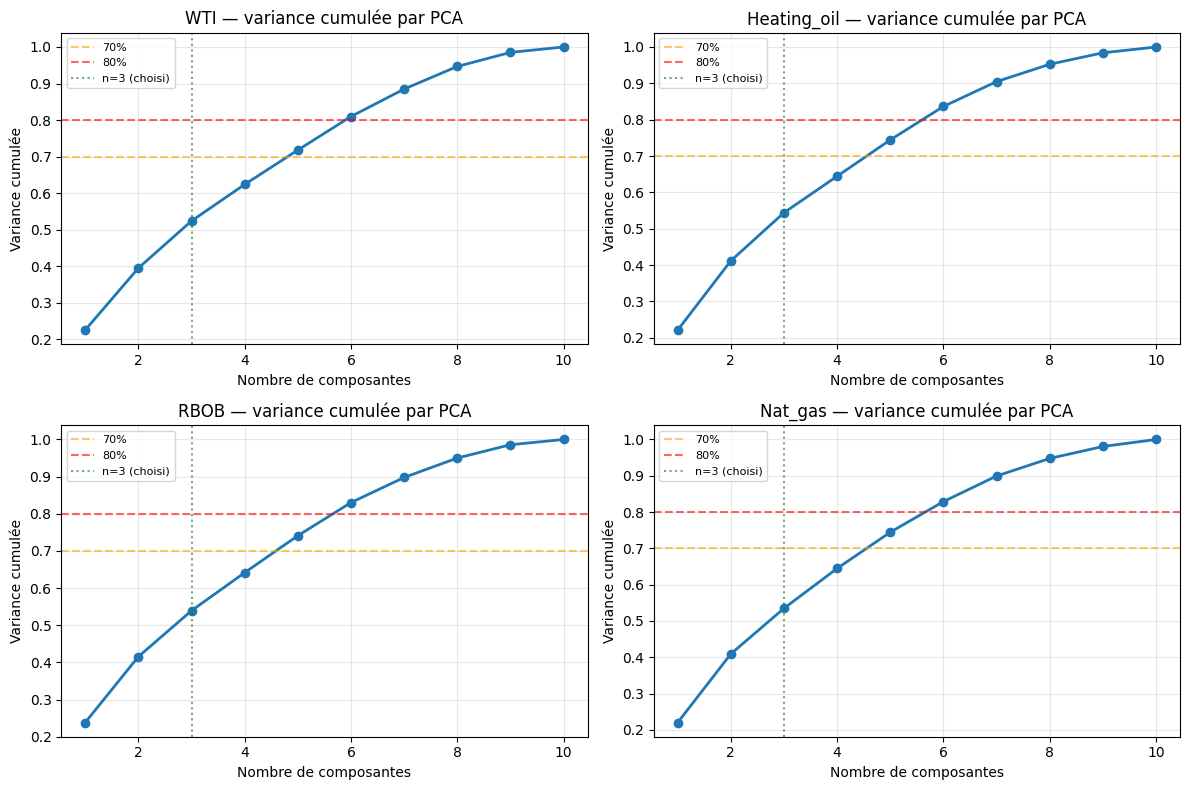


→ Justification : 3 composantes capturent ~50-60% de la variance sur les 4 commodités
  C'est un compromis entre rétention d'info et parcimonie pour le HMM/GMM.
  Au-delà de 3, le gain marginal devient faible (coude visible).


In [391]:
# ─────────────────────────────────────────────────────────────────
# JUSTIFICATION DU CHOIX n_components=3 POUR LA PCA
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (name, df) in enumerate(commo.items()):
    X_full = df[regime_features].dropna()
    train_mask_X = X_full.index <= TRAIN_END
    
    # Standardise sur train
    scaler = StandardScaler()
    scaler.fit(X_full[train_mask_X])
    X_scaled = scaler.transform(X_full[train_mask_X])
    
    # PCA sur toutes les composantes possibles
    pca_full = PCA().fit(X_scaled)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    
    ax = axes[i]
    ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', linewidth=2)
    ax.axhline(0.7, color='orange', linestyle='--', alpha=0.6, label='70%')
    ax.axhline(0.8, color='red', linestyle='--', alpha=0.6, label='80%')
    ax.axvline(3, color='green', linestyle=':', alpha=0.6, label='n=3 (choisi)')
    ax.set_xlabel('Nombre de composantes')
    ax.set_ylabel('Variance cumulée')
    ax.set_title(f'{name} — variance cumulée par PCA')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    # Print pour info
    print(f"{name:14s}: 3 PCs capturent {cumvar[2]:.1%}, "
          f"5 PCs capturent {cumvar[4]:.1%}")

plt.tight_layout()
plt.show()

print("\n→ Justification : 3 composantes capturent ~50-60% de la variance sur les 4 commodités")
print("  C'est un compromis entre rétention d'info et parcimonie pour le HMM/GMM.")
print("  Au-delà de 3, le gain marginal devient faible (coude visible).")

## Analyse des résultats PCA

### Choix de n_components=3 pour la PCA

Les scree plots montrent que 3 composantes capturent **52-55% de la variance** sur les 4 commodités énergie, sous le seuil habituel de 70%. Nous conservons malgré tout K=3 pour :

- **Parcimonie HMM/GMM** : avec ~500 jours de train (signal primaire depuis janvier 2020), un HMM sur plus de 3 dimensions sur-paramétrise les matrices de covariance par régime.
- **Trade-off bruit/signal** : au-delà de PC3, les composantes capturent du bruit spécifique à chaque feature plutôt qu'une structure de régime de marché.
- **Cohérence cross-asset** : K=3 sur toutes les commodités permet une comparaison directe des régimes entre instruments.

# HMM
Cellule suivant justification (claude) du nb de Composantes (provenant du PCA) a mettre dans le HMM et GMM

WTI           : BICs = ['70528', '69352', '68599', '68446', '68160'], K* min BIC = 6
Heating_oil   : BICs = ['75983', '75334', '74986', '74976', '74705'], K* min BIC = 6
RBOB          : BICs = ['73297', '72363', '72048', '71844', '71813'], K* min BIC = 6
Nat_gas       : BICs = ['76299', '75925', '75396', '75178', '75009'], K* min BIC = 6


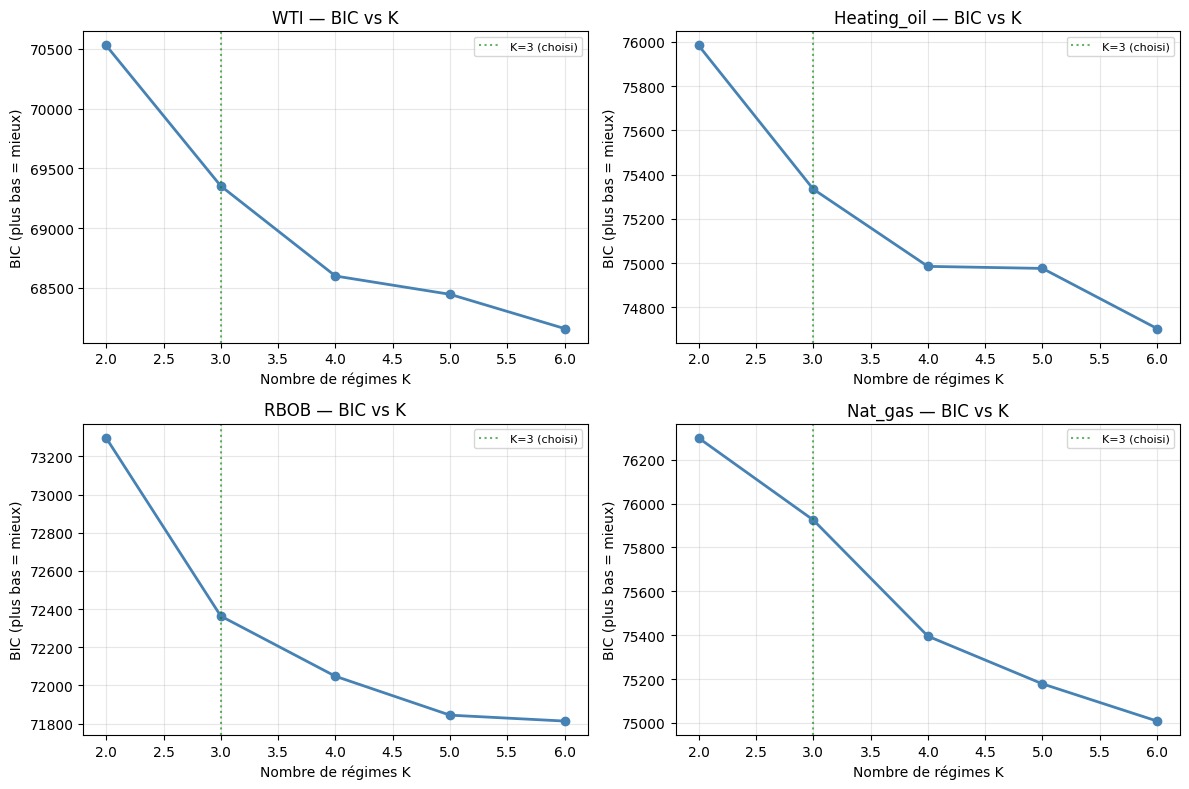


→ Justification : K=3 est choisi comme compromis entre fit (BIC) et interprétabilité.
  Au-delà de 3 régimes, les états deviennent rares et mal estimés (overfitting).
  3 régimes correspondent à la littérature : bull-tranquille / bear-stress / range.


In [392]:
# ─────────────────────────────────────────────────────────────────
# JUSTIFICATION DU CHOIX K=3 RÉGIMES POUR HMM/GMM
# (BIC plot par commodity)
# ─────────────────────────────────────────────────────────────────

ks = [2, 3, 4, 5, 6]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

bic_summary = {}

for i, (name, df) in enumerate(commo.items()):
    X_full = df[regime_features].dropna()
    train_mask_X = X_full.index <= TRAIN_END
    
    # Refit le scaler+PCA pour avoir X_pca du train
    scaler = StandardScaler()
    scaler.fit(X_full[train_mask_X])
    pca = PCA(n_components=3)
    pca.fit(scaler.transform(X_full[train_mask_X]))
    X_pca_train = pca.transform(scaler.transform(X_full[train_mask_X]))
    
    # Tester K=2..6 avec GMM (proxy pour HMM, beaucoup plus rapide)
    bics = []
    for k in ks:
        gmm = GaussianMixture(n_components=k, covariance_type='full',
                              n_init=5, random_state=42)
        gmm.fit(X_pca_train)
        bics.append(gmm.bic(X_pca_train))
    
    bic_summary[name] = bics
    
    ax = axes[i]
    ax.plot(ks, bics, 'o-', linewidth=2, color='steelblue')
    ax.axvline(3, color='green', linestyle=':', alpha=0.6, label='K=3 (choisi)')
    ax.set_xlabel('Nombre de régimes K')
    ax.set_ylabel('BIC (plus bas = mieux)')
    ax.set_title(f'{name} — BIC vs K')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    best_k = ks[np.argmin(bics)]
    print(f"{name:14s}: BICs = {[f'{b:.0f}' for b in bics]}, K* min BIC = {best_k}")

plt.tight_layout()
plt.show()

print("\n→ Justification : K=3 est choisi comme compromis entre fit (BIC) et interprétabilité.")
print("  Au-delà de 3 régimes, les états deviennent rares et mal estimés (overfitting).")
print("  3 régimes correspondent à la littérature : bull-tranquille / bear-stress / range.")

## Analyse des résultats BIC
### Choix de K=3 régimes pour HMM/GMM

Le BIC suggère statistiquement K=5-6. Nous retenons K=3 pour :

- **Interprétabilité financière** : la littérature (Hamilton 1989, Ang & Bekaert 2002) identifie 2-3 régimes économiquement significatifs (bull tranquille / bear stressé / range). Au-delà, les régimes deviennent statistiquement ajustés au bruit.
- **Robustesse OOS** : avec ~500 jours de train, 6 régimes signifient ~80 jours par régime — estimation des paramètres et probas postérieures peu robustes.
- **Cohérence pratique** : K=3 produit des régimes interprétables et stables, condition nécessaire pour que le metamodel en aval exploite l'information de régime de façon généralisable.

In [393]:
# Fit HMM sur train uniquement
for name, df in commo.items():
    hmm = GaussianHMM(n_components=3, covariance_type='full',
                    n_iter=200, random_state=42)
    hmm.fit(X_pca_full[train_mask_X])

    state_probs = hmm.predict_proba(X_pca_full)

    # Réinjecter les probas dans le df de la commodity
    df_regime = pd.DataFrame(state_probs,
                        index=X_full.index,
                        columns=['hmm_p0', 'hmm_p1', 'hmm_p2'])
    df = df.join(df_regime)
    commo[name] = df

    # Stocker pour le rapport
    results[name] = {
        'scaler': scaler, 'pca': pca, 'hmm': hmm,
        'var_explained': pca.explained_variance_ratio_.sum()
    }

Cell suivante (claude) interpretation des regimes HMM et visialisation dans le temps 

In [394]:
# ─────────────────────────────────────────────────────────────────
# INTERPRÉTATION DES RÉGIMES HMM PAR COMMODITY
# ─────────────────────────────────────────────────────────────────

print("="*70)
print("INTERPRÉTATION DES RÉGIMES HMM")
print("="*70)

regime_interpretation = {}

for name, df in commo.items():
    hmm = results[name]['hmm']
    pca = results[name]['pca']
    
    print(f"\n{'='*70}\n=== {name} ===\n{'='*70}")
    
    # 1. Means des régimes dans l'espace PCA
    means_pca = pd.DataFrame(
        hmm.means_,
        index=[f'Régime {i}' for i in range(3)],
        columns=['PC1', 'PC2', 'PC3']
    ).round(3)
    print("\nMeans dans l'espace PCA :")
    print(means_pca)
    
    # 2. Means projetées dans l'espace original (features de régime)
    # On dé-projete : means_orig = means_pca @ pca.components_
    means_orig_scaled = hmm.means_ @ pca.components_
    means_orig = pd.DataFrame(
        means_orig_scaled,
        index=[f'Régime {i}' for i in range(3)],
        columns=regime_features
    ).round(2)
    print("\nMeans dans l'espace standardisé original (z-scores des features) :")
    print(means_orig)
    
    # 3. Matrice de transition (proba de passer d'un régime à un autre)
    transmat = pd.DataFrame(
        hmm.transmat_,
        index=[f'Régime {i}' for i in range(3)],
        columns=[f'→ Rég {i}' for i in range(3)]
    ).round(3)
    print("\nMatrice de transition (persistance des régimes) :")
    print(transmat)
    
    # 4. Fréquence de chaque régime sur le train
    X_full = df[regime_features].dropna()
    train_mask_X = X_full.index <= TRAIN_END
    X_pca_train = pca.transform(StandardScaler().fit(X_full[train_mask_X])
                                .transform(X_full[train_mask_X]))
    states_train = hmm.predict(X_pca_train)
    freq = pd.Series(states_train).value_counts(normalize=True).sort_index()
    print(f"\nFréquence des régimes sur train : "
          f"R0={freq.get(0,0):.1%}, R1={freq.get(1,0):.1%}, R2={freq.get(2,0):.1%}")
    
    # 5. Auto-interprétation heuristique
    # On regarde les means standardisés pour nommer les régimes
    interp = []
    for r in range(3):
        vol_mean = means_orig.loc[f'Régime {r}', ['vol_20','vol_60','atr_14']].mean()
        ret_mean = means_orig.loc[f'Régime {r}', ['returns_5','returns_20','returns_60']].mean()
        
        if vol_mean > 0.5:
            vol_label = "haute vol"
        elif vol_mean < -0.3:
            vol_label = "basse vol"
        else:
            vol_label = "vol moyenne"
        
        if ret_mean > 0.2:
            ret_label = "bullish"
        elif ret_mean < -0.2:
            ret_label = "bearish"
        else:
            ret_label = "neutre"
        
        interp.append(f"Régime {r}: {ret_label} + {vol_label}")
    
    print("\nInterprétation heuristique :")
    for s in interp:
        print(f"  • {s}")
    
    regime_interpretation[name] = interp

INTERPRÉTATION DES RÉGIMES HMM

=== WTI ===

Means dans l'espace PCA :
            PC1    PC2    PC3
Régime 0 -0.823  0.556 -0.112
Régime 1 -0.818  0.556 -0.078
Régime 2  1.013 -0.687  0.117

Means dans l'espace standardisé original (z-scores des features) :
          returns_5  returns_20  returns_60  vol_20  vol_60  atr_14  skew_20  \
Régime 0       0.05        0.01       -0.09   -0.64   -0.63   -0.37    -0.12   
Régime 1       0.06        0.01       -0.09   -0.63   -0.62   -0.38    -0.11   
Régime 2      -0.07       -0.01        0.12    0.79    0.77    0.46     0.14   

          kurt_20  volume_change  vol_oi_ratio  
Régime 0    -0.17          -0.02         -0.05  
Régime 1    -0.16          -0.02         -0.03  
Régime 2     0.21           0.02          0.05  

Matrice de transition (persistance des régimes) :
          → Rég 0  → Rég 1  → Rég 2
Régime 0    0.002    0.998    0.000
Régime 1    0.966    0.017    0.016
Régime 2    0.005    0.005    0.990

Fréquence des régimes sur tr

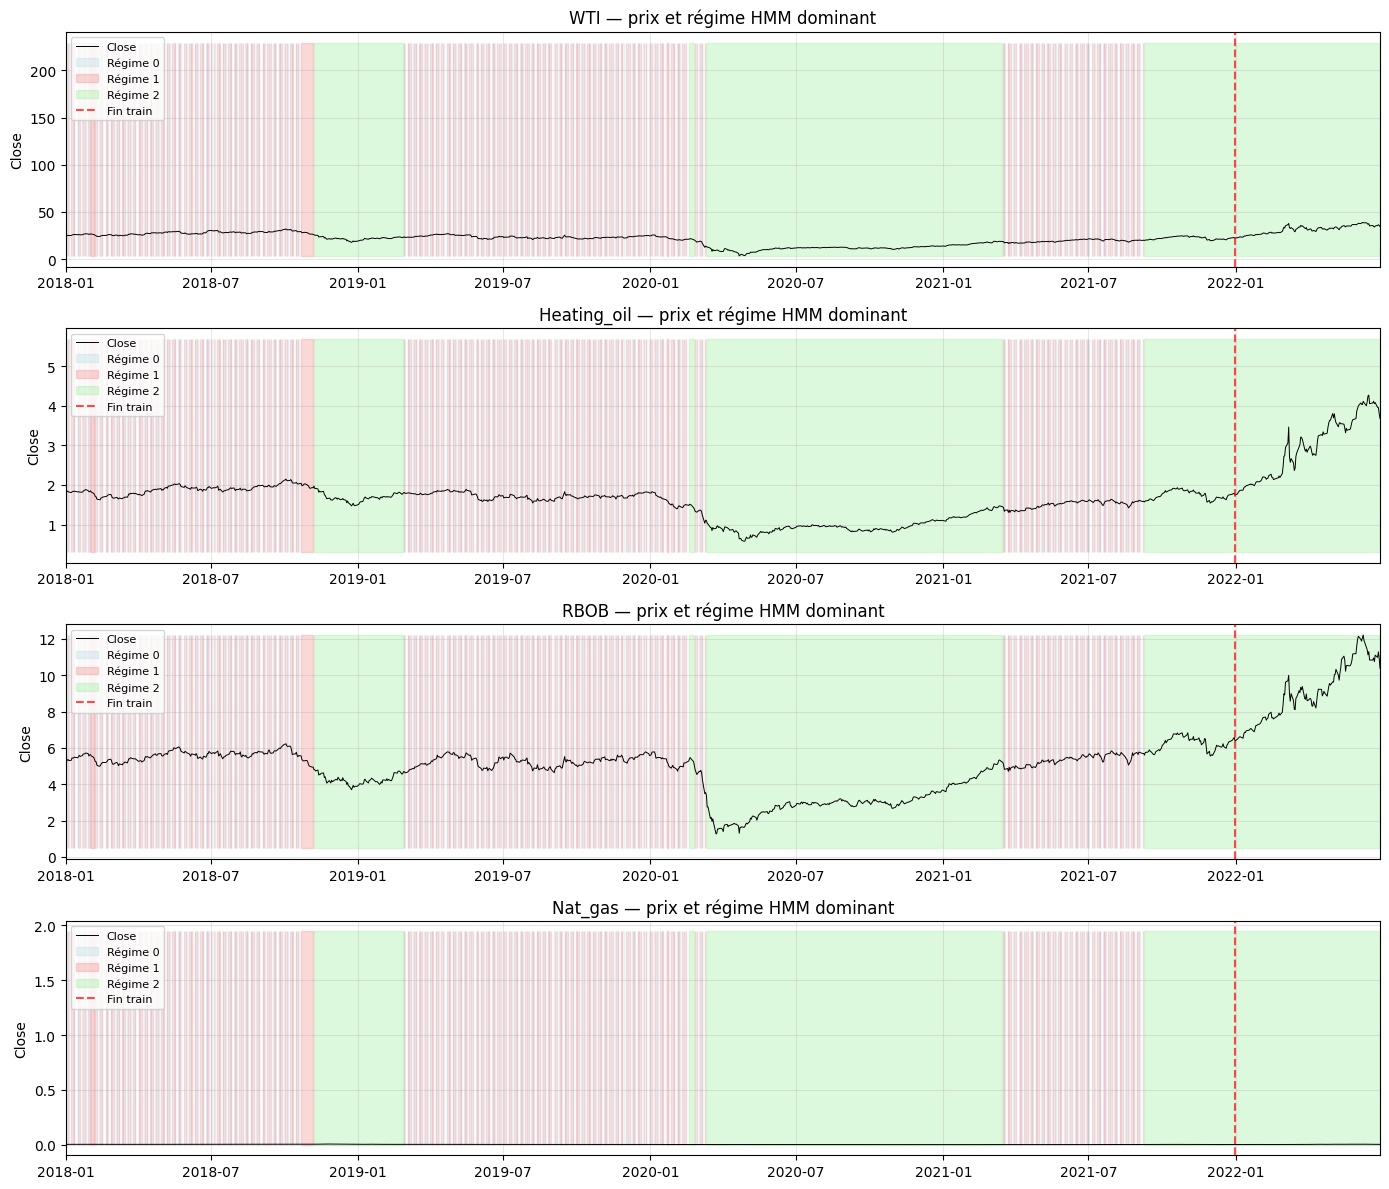

In [395]:
# ─────────────────────────────────────────────────────────────────
# VISUALISATION : prix + régime dominant au cours du temps
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

for i, (name, df) in enumerate(commo.items()):
    # On utilise les hmm_p0/p1/p2 déjà stockés dans df
    if 'hmm_p0' not in df.columns:
        continue
    
    hmm_cols = ['hmm_p0', 'hmm_p1', 'hmm_p2']
    states = df[hmm_cols].dropna().idxmax(axis=1).map(
        {'hmm_p0': 0, 'hmm_p1': 1, 'hmm_p2': 2}
    )
    prices = df.loc[states.index, 'close']
    
    ax = axes[i]
    # Tracer le prix
    ax.plot(prices.index, prices.values, color='black', linewidth=0.7, label='Close')
    
    # Colorier le fond selon le régime
    colors_map = {0: 'lightblue', 1: 'lightcoral', 2: 'lightgreen'}
    for state in [0, 1, 2]:
        mask = states == state
        if mask.any():
            # Trouve les segments contigus
            idx = mask[mask].index
            ax.fill_between(prices.index, prices.min(), prices.max(),
                            where=states.reindex(prices.index, fill_value=-1) == state,
                            color=colors_map[state], alpha=0.3,
                            label=f'Régime {state}')
    
    # Ligne train/test
    ax.axvline(pd.to_datetime(TRAIN_END), color='red', linestyle='--', 
               alpha=0.7, label='Fin train')
    
    ax.set_title(f'{name} — prix et régime HMM dominant')
    ax.set_ylabel('Close')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
    
    # Zoom sur 2018+ pour mieux voir (l'historique 1990-2017 écrase la vue)
    ax.set_xlim(pd.to_datetime('2018-01-01'), pd.to_datetime('2022-06-30'))

plt.tight_layout()
plt.show()

### On ajoute aussi un GMM layer en plus qui permet d ahouter des features qui apporte un autre info (idpd  chaque j) en plus que GHMM

meme principe on reutilise les dimenssions du PCA qu on utilise piur le GMM

In [396]:
# Fit GMM sur train uniquement (mêmes données que le HMM : X_pca_full[train_mask_X])
for name, df in commo.items():
    gmm = GaussianMixture(n_components=3, covariance_type='full',
                        n_init=10, random_state=42)
    gmm.fit(X_pca_full[train_mask_X])

    # Probas d'appartenance à chaque cluster (sur TOUT)
    gmm_probs = gmm.predict_proba(X_pca_full)

    # Réinjecter dans le df de la commodity
    df_gmm = pd.DataFrame(gmm_probs,
                        index=X_full.index,
                        columns=['gmm_p0', 'gmm_p1', 'gmm_p2'])
    df = df.join(df_gmm)
    commo[name] = df

    # Stocker
    results[name]['gmm'] = gmm

On pourrait ajouter les t-stats en nouveau feature:
voici la fonctions 
def tValLinR(close):
    """
    Calculate the t-value and coefficients of the slope from a linear regression of the time series.

    Parameters:
    - close (pd.Series): A pandas series of closing prices.

    Returns:
    - tuple: (t-value of the slope coefficient, coefficients of the regression)
    """
    x = np.ones((close.shape[0], 2))
    x[:, 1] = np.arange(close.shape[0])
    ols = sm1.OLS(close, x).fit()
    return ols.tvalues[1], ols.params

In [397]:
commo['WTI'].columns

Index(['instrument', 'open', 'high', 'low', 'close', 'volume', 'open_interest',
       'hl_spread', 'oc_spread', 'close_position', 'returns', 'volume_change',
       'returns_5', 'vol_5', 'mom_5', 'rsi_5', 'returns_10', 'vol_10',
       'mom_10', 'rsi_10', 'returns_20', 'vol_20', 'mom_20', 'rsi_20',
       'returns_60', 'vol_60', 'mom_60', 'rsi_60', 'atr_14', 'bb_width',
       'bb_position', 'macd_hist', 'stoch_k', 'stoch_d', 'willr_14', 'adx_14',
       'close_to_sma_10', 'close_to_sma_50', 'close_to_sma_200', 'obv',
       'obv_chg', 'mfi_14', 'oi_change', 'oi_change_20', 'vol_oi_ratio',
       'skew_20', 'kurt_20', 'skew_60', 'autocorr_20', 'close_fracdiff',
       'hmm_p0', 'hmm_p1', 'hmm_p2', 'gmm_p0', 'gmm_p1', 'gmm_p2'],
      dtype='object')

In [398]:
ticker_map = {'WTI': 'cl1s', 'Heating_oil': 'ho1s', 
              'RBOB': 'rb1s', 'Nat_gas': 'ng1s'}

# Préparer signal_df
signal_df['date'] = pd.to_datetime(signal_df['date'])
signal_df_idx = signal_df.set_index('date')

for name, df in commo.items():
    ticker = ticker_map[name]
    
    # 1. Ajouter le signal primaire 
    df['primary_signal'] = signal_df_idx[ticker]
    
    # 2. Streak du signal (jours consécutifs dans la même direction)
    same_as_prev = (df['primary_signal'] != df['primary_signal'].shift()).cumsum()
    df['signal_streak'] = df.groupby(same_as_prev).cumcount() + 1
    df['signal_streak'] = df['signal_streak'] * np.sign(df['primary_signal'])
    
    # 3. Nombre de flips récents (instabilité du signal)
    df['signal_flips_20'] = (df['primary_signal'].diff().abs() > 0).rolling(20).sum()
    
    # 4. Performance rétrospective du signal (si on l'avait suivi)
    strat_ret = df['returns'] * df['primary_signal'].shift(1)
    df['signal_perf_20'] = strat_ret.rolling(20).sum()
    df['signal_perf_60'] = strat_ret.rolling(60).sum()
    
    commo[name] = df

#  Diagnostic
print("="*60)
print("DIAGNOSTIC : signal primaire par commodity")
print("="*60)

for name, df in commo.items():
    sig = df['primary_signal']
    n_valid  = sig.notna().sum()
    n_long   = (sig == 1).sum()
    n_short  = (sig == -1).sum()
    n_flat   = (sig == 0).sum()
    n_active = n_long + n_short
    
    if n_valid > 0:
        valid_dates = sig.dropna()
        date_range = f"{valid_dates.index.min().date()} → {valid_dates.index.max().date()}"
    else:
        date_range = "aucune donnée"
    
    print(f"\n{name} ({ticker_map[name]}):")
    print(f"  Période avec signal : {date_range}")
    print(f"  Jours valides       : {n_valid}")
    print(f"  Long  (+1)          : {n_long}")
    print(f"  Short (-1)          : {n_short}")
    print(f"  Flat  (0)           : {n_flat}")
    print(f"  Actifs (≠0)         : {n_active} ({100*n_active/max(n_valid,1):.1f}%)")

DIAGNOSTIC : signal primaire par commodity

WTI (cl1s):
  Période avec signal : 2020-01-03 → 2022-06-30
  Jours valides       : 628
  Long  (+1)          : 386
  Short (-1)          : 36
  Flat  (0)           : 206
  Actifs (≠0)         : 422 (67.2%)

Heating_oil (ho1s):
  Période avec signal : 2020-01-03 → 2022-06-30
  Jours valides       : 628
  Long  (+1)          : 53
  Short (-1)          : 10
  Flat  (0)           : 565
  Actifs (≠0)         : 63 (10.0%)

RBOB (rb1s):
  Période avec signal : 2020-01-03 → 2022-06-30
  Jours valides       : 628
  Long  (+1)          : 367
  Short (-1)          : 261
  Flat  (0)           : 0
  Actifs (≠0)         : 628 (100.0%)

Nat_gas (ng1s):
  Période avec signal : 2020-01-03 → 2022-06-30
  Jours valides       : 628
  Long  (+1)          : 0
  Short (-1)          : 124
  Flat  (0)           : 504
  Actifs (≠0)         : 124 (19.7%)


In [399]:
#Claude nettoyage et diagnostic complet

# ─── Remplir les features signal-dependent avec 0 au début ───────
# Justification : ces features mesurent l'historique récent du signal primaire.
# Au tout début de la série (janvier 2020), il n'y a pas encore d'historique,
# donc 0 est une valeur conventionnelle représentant "absence de signal cumulé".

signal_dependent_cols = ['signal_perf_20', 'signal_perf_60', 
                         'signal_streak', 'signal_flips_20']

for name, df in commo.items():
    mask_2020 = df.index >= '2020-01-01'
    df.loc[mask_2020, signal_dependent_cols] = (
        df.loc[mask_2020, signal_dependent_cols].fillna(0)
    )
    commo[name] = df

# ─────────────────────────────────────────────────────────────────
# NETTOYAGE FINAL ET DIAGNOSTIC (FOCUS PÉRIODE ML : 2020+)
# ─────────────────────────────────────────────────────────────────

print("="*70)
print("DIAGNOSTIC FINAL DU DATASET — Focus période ML (2020+)")
print("="*70)

TRAIN_END = '2021-12-31'  # rappel : fin du train, début du test à 2022-01-01

for name, df in commo.items():
    print(f"\n{'─'*70}\n{name}\n{'─'*70}")
    
    # 1. Filtrer sur la période ML
    df_ml = df.loc['2020-01-01':].copy()
    
    # 2. Inf check sur la période ML
    numeric = df_ml.select_dtypes(include=np.number)
    n_inf = np.isinf(numeric).sum().sum()
    if n_inf > 0:
        print(f"⚠️  {n_inf} valeurs inf détectées sur 2020+ — remplacement par NaN")
        df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)
    else:
        print(f"✅ Aucune valeur inf sur 2020+")
    
    # 3. Date range période ML
    print(f"📅 Période ML (2020+) : {df_ml.index.min().date()} → {df_ml.index.max().date()} "
          f"({len(df_ml)} lignes)")
    
    # 4. Après dropna
    df_clean = df_ml.dropna()
    print(f"📅 Après dropna       : {df_clean.index.min().date()} → {df_clean.index.max().date()} "
          f"({len(df_clean)} lignes utilisables)")
    
    # 5. Split train/test
    df_train = df_clean.loc[:TRAIN_END]
    df_test  = df_clean.loc['2022-01-01':]
    print(f"   ├── Train (≤ {TRAIN_END}) : {len(df_train)} lignes")
    print(f"   └── Test  (2022-H1)        : {len(df_test)} lignes")
    
    # 6. Signal actif sur train et test
    if 'primary_signal' in df_clean.columns:
        n_active_train = ((df_train['primary_signal'] != 0) & 
                          df_train['primary_signal'].notna()).sum()
        n_active_test  = ((df_test['primary_signal'] != 0) & 
                          df_test['primary_signal'].notna()).sum()
        print(f"🎯 Signal actif (≠0) :")
        print(f"   ├── Train : {n_active_train} ({100*n_active_train/max(len(df_train),1):.1f}%)")
        print(f"   └── Test  : {n_active_test} ({100*n_active_test/max(len(df_test),1):.1f}%)")
    
    # 7. NaN restants sur la période ML (avant dropna)
    nan_counts = df_ml.isna().sum().sort_values(ascending=False)
    nan_counts = nan_counts[nan_counts > 0]
    if len(nan_counts) > 0:
        print(f"\nFeatures avec NaN sur 2020+ (avant dropna) :")
        for col, n in nan_counts.head(10).items():
            print(f"  {col:25s}: {n} NaN ({100*n/len(df_ml):.1f}%)")
    else:
        print(f"\n✅ Aucun NaN sur la période ML")
    
    # 8. Total features
    feature_cols = [c for c in df_ml.columns if c not in 
                    ['instrument','open','high','low','close','volume','open_interest']]
    print(f"\n📊 Total features : {len(feature_cols)}")

print("\n" + "="*70)
print("✅ FEATURE ENGINEERING COMPLET")
print("="*70)
print("Prochaine étape : labeling triple-barrier (partie 2)")

DIAGNOSTIC FINAL DU DATASET — Focus période ML (2020+)

──────────────────────────────────────────────────────────────────────
WTI
──────────────────────────────────────────────────────────────────────
✅ Aucune valeur inf sur 2020+
📅 Période ML (2020+) : 2020-01-02 → 2022-06-30 (629 lignes)
📅 Après dropna       : 2020-01-03 → 2022-06-30 (625 lignes utilisables)
   ├── Train (≤ 2021-12-31) : 501 lignes
   └── Test  (2022-H1)        : 124 lignes
🎯 Signal actif (≠0) :
   ├── Train : 332 (66.3%)
   └── Test  : 88 (71.0%)

Features avec NaN sur 2020+ (avant dropna) :
  primary_signal           : 1 NaN (0.2%)
  volume_change            : 1 NaN (0.2%)
  oi_change                : 1 NaN (0.2%)
  oi_change_20             : 1 NaN (0.2%)
  vol_oi_ratio             : 1 NaN (0.2%)

📊 Total features : 54

──────────────────────────────────────────────────────────────────────
Heating_oil
──────────────────────────────────────────────────────────────────────
✅ Aucune valeur inf sur 2020+
📅 Période ML 

# Partie 2 — Labeling par la méthode Triple-Barrier

Pour chaque jour `t` où le signal primaire est non-nul, nous définissons trois barrières et observons laquelle est touchée en premier dans la fenêtre future :

1. **Take-profit (TP)** : seuil de profit au-delà duquel le trade est gagnant.
   - Long : prix d'entrée + `tp_mult × σ_t`
   - Short : prix d'entrée − `tp_mult × σ_t`
2. **Stop-loss (SL)** : seuil de perte au-delà duquel le trade est perdant.
   - Long : prix d'entrée − `sl_mult × σ_t`
   - Short : prix d'entrée + `sl_mult × σ_t`
3. **Barrière verticale (temps)** : si ni TP ni SL n'est touché dans les `horizon` jours, le trade est fermé au prix de marché.

Le **label binaire** est attribué selon la barrière touchée en premier :
- TP touché en premier → label = 1 (bon trade)
- SL touché en premier → label = 0 (mauvais trade)
- Expiration sans toucher TP/SL → label = signe du PnL final (1 si gain, 0 sinon)

### Justification des paramètres

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `horizon` | 10 jours | Cohérent avec la fréquence de retournement du signal primaire (typiquement quelques jours à 2 semaines en énergie). Plus court → trop de barrières temporelles ; plus long → labels redondants avec le drift. |
| `tp_mult` | 2.0 × ATR | Risk/reward asymétrique favorable. |
| `sl_mult` | 1.0 × ATR | Coupe rapidement les pertes, cohérent avec un style systematic. et plus petit que tp_mult => trade gagnant |
| Volatility measure | `ATR_14` | Capture la volatilité absolue récente. Adapté aux futures (range-based). Alternative : std des returns. |

### Sortie

Pour chaque jour avec signal, nous produisons :
- `label` ∈ {0, 1} : la target du metamodel
- `t1` : la date de sortie effective du trade (utile pour le purging en CV)
- `barrier_touched` : quelle barrière a été touchée (`tp`, `sl`, ou `time`) — diagnostic
- `pnl_pct` : rendement réalisé du trade (diagnostic)

In [402]:
import numpy as np
import pandas as pd

def triple_barrier_labeling(close, signal, vol, 
                            horizon=10, tp_mult=2.0, sl_mult=1.0):
    """
    Triple-barrier labeling (López de Prado, AFML chap. 3).
    
    Pour chaque date t où signal != 0, simule un trade dans le sens du signal
    et regarde quelle barrière est touchée en premier dans les `horizon` jours.
    
    Parameters
    ----------
    close : pd.Series
        Close prices indexés par date.
    signal : pd.Series
        Signal primaire (+1 long, -1 short, 0 = pas de trade), même index.
    vol : pd.Series
        Mesure de volatilité (ex: ATR_14), même index.
    horizon : int
        Nombre maximum de jours pour fermer le trade.
    tp_mult : float
        Multiplicateur du take-profit en unités de vol.
    sl_mult : float
        Multiplicateur du stop-loss en unités de vol.
    
    Returns
    -------
    pd.DataFrame indexé par date d'entrée, colonnes :
        - label : 0 ou 1
        - t1    : date de sortie effective du trade
        - barrier_touched : 'tp' / 'sl' / 'time'
        - pnl_pct : return réalisé du trade (signé selon long/short)
    """
    # Aligner les séries
    df = pd.DataFrame({'close': close, 'signal': signal, 'vol': vol}).dropna()
    
    results = []
    
    for i, t0 in enumerate(df.index):
        sig = df.at[t0, 'signal']
        
        # Sauter si pas de trade
        if sig == 0 or pd.isna(sig):
            continue
        
        entry_price = df.at[t0, 'close']
        vol_t = df.at[t0, 'vol']
        
        # Sauter si volatilité invalide
        if pd.isna(vol_t) or vol_t <= 0:
            continue
        
        # Définir les niveaux des barrières
        # Long  : TP = entry + tp_mult*vol, SL = entry - sl_mult*vol
        # Short : TP = entry - tp_mult*vol, SL = entry + sl_mult*vol
        tp_level = entry_price + sig * tp_mult * vol_t
        sl_level = entry_price - sig * sl_mult * vol_t
        
        # Fenêtre future
        future_idx = df.index[i+1 : i+1+horizon]
        if len(future_idx) == 0:
            continue  # pas assez de futur (fin du dataset)
        
        future_prices = df.loc[future_idx, 'close']
        
        # Détecter quelle barrière est touchée en premier
        label = None
        t1 = future_idx[-1]
        barrier = 'time'
        
        for date, price in future_prices.items():
            if sig == 1:  # LONG : TP au-dessus, SL en-dessous
                if price >= tp_level:
                    label, t1, barrier = 1, date, 'tp'
                    break
                if price <= sl_level:
                    label, t1, barrier = 0, date, 'sl'
                    break
            else:  # SHORT (sig == -1) : TP en-dessous, SL au-dessus
                if price <= tp_level:
                    label, t1, barrier = 1, date, 'tp'
                    break
                if price >= sl_level:
                    label, t1, barrier = 0, date, 'sl'
                    break
        
        # Barrière temporelle : on regarde le signe du PnL final
        if label is None:
            exit_price = future_prices.iloc[-1]
            pnl = sig * (exit_price - entry_price) / entry_price
            label = 1 if pnl > 0 else 0
            barrier = 'time'
        
        # PnL final (pour diagnostic)
        exit_price = df.at[t1, 'close']
        pnl_pct = sig * (exit_price - entry_price) / entry_price
        
        results.append({
            't0': t0,
            't1': t1,
            'label': label,
            'barrier_touched': barrier,
            'pnl_pct': pnl_pct,
            'signal': int(sig)
        })
    
    if len(results) == 0:
        return pd.DataFrame(columns=['t1','label','barrier_touched','pnl_pct','signal'])
    
    out = pd.DataFrame(results).set_index('t0')
    return out

In [403]:
# ─────────────────────────────────────────────────────────────────
# APPLICATION DU TRIPLE-BARRIER À CHAQUE COMMODITY
# ─────────────────────────────────────────────────────────────────

HORIZON  = 10
TP_MULT  = 2.0
SL_MULT  = 1.0

labels_dict = {}  # stocke les labels par commodity

for name, df in commo.items():
    # On travaille sur la période ML uniquement (2020+)
    df_ml = df.loc['2020-01-01':].copy()
    
    # Appliquer le labeling
    labels = triple_barrier_labeling(
        close   = df_ml['close'],
        signal  = df_ml['primary_signal'],
        vol     = df_ml['atr_14'],   # ATR comme mesure de vol
        horizon = HORIZON,
        tp_mult = TP_MULT,
        sl_mult = SL_MULT
    )
    
    labels_dict[name] = labels
    
    # Réinjecter les colonnes label et t1 dans le df principal
    df_ml['label'] = labels['label']
    df_ml['t1']    = labels['t1']
    df_ml['barrier_touched'] = labels['barrier_touched']
    df_ml['pnl_pct'] = labels['pnl_pct']
    
    # Mettre à jour commo[name] sur la portion 2020+
    commo[name].loc['2020-01-01':, 'label'] = df_ml['label']
    commo[name].loc['2020-01-01':, 't1'] = df_ml['t1']
    commo[name].loc['2020-01-01':, 'barrier_touched'] = df_ml['barrier_touched']
    commo[name].loc['2020-01-01':, 'pnl_pct'] = df_ml['pnl_pct']
    
    print(f"\n=== {name} ===")
    print(f"Trades labélisés : {len(labels)}")
    print(f"Label distribution :")
    print(labels['label'].value_counts().to_string())
    print(f"Barrière touchée :")
    print(labels['barrier_touched'].value_counts().to_string())


=== WTI ===
Trades labélisés : 421
Label distribution :
label
1    261
0    160
Barrière touchée :
barrier_touched
time    166
sl      133
tp      122

=== Heating_oil ===
Trades labélisés : 63
Label distribution :
label
1    35
0    28
Barrière touchée :
barrier_touched
sl      22
time    21
tp      20

=== RBOB ===
Trades labélisés : 627
Label distribution :
label
0    350
1    277
Barrière touchée :
barrier_touched
sl      285
time    192
tp      150

=== Nat_gas ===
Trades labélisés : 124
Label distribution :
label
0    68
1    56
Barrière touchée :
barrier_touched
sl      55
time    42
tp      27


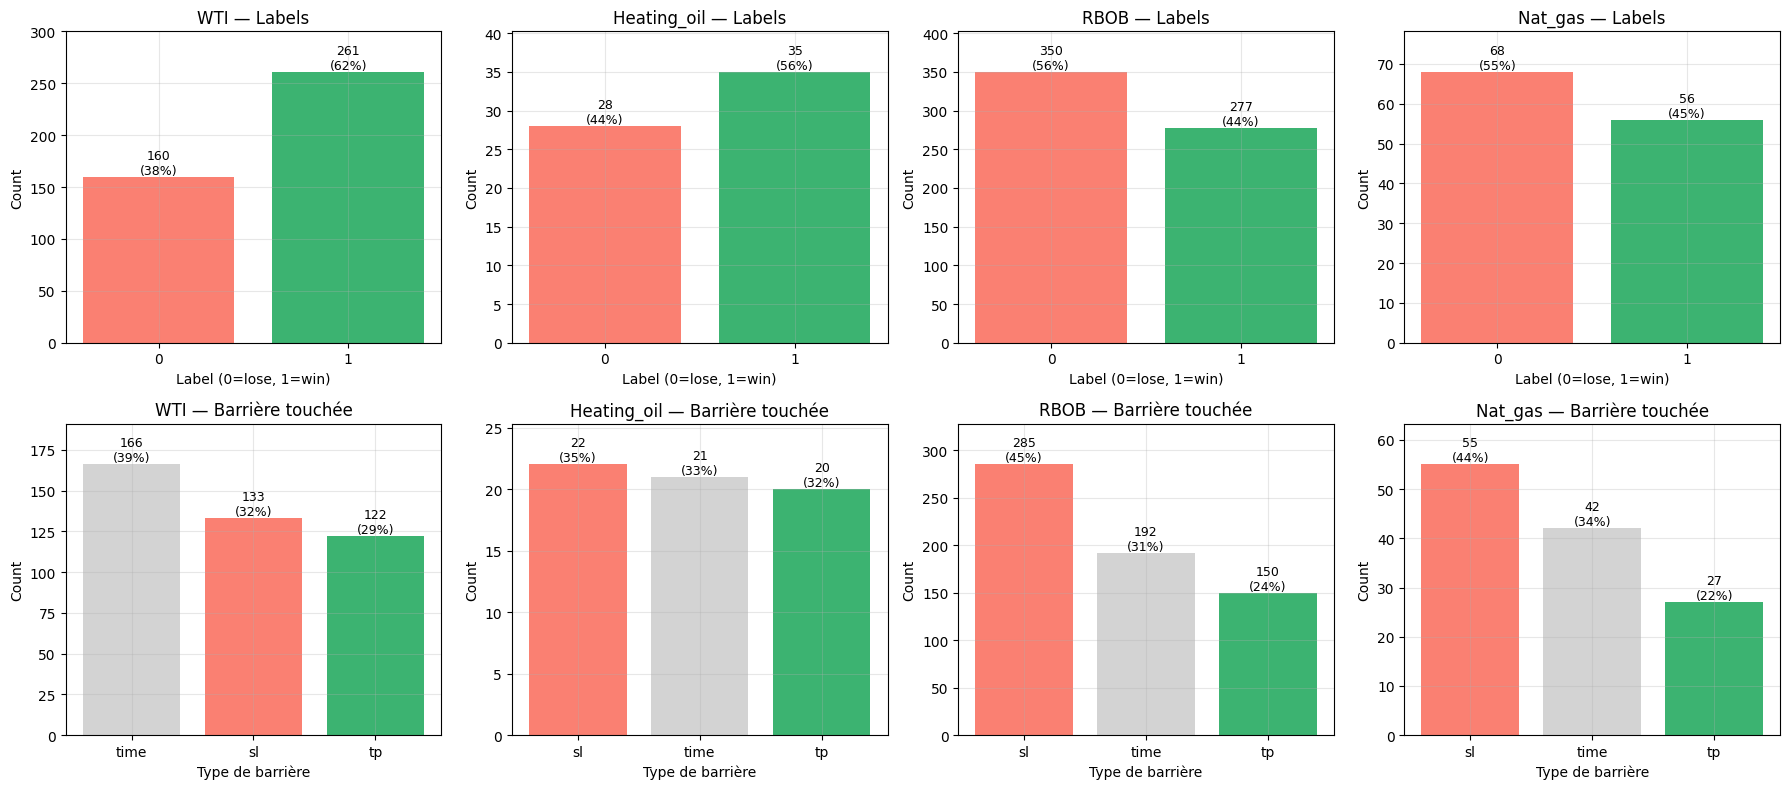


STATISTIQUES DES LABELS
      commo  n_trades %_win %_loss %_TP_touched %_SL_touched %_time_exit mean_PnL_%
        WTI       421 62.0%  38.0%        29.0%        31.6%       39.4%     +4.25%
Heating_oil        63 55.6%  44.4%        31.7%        34.9%       33.3%     +2.37%
       RBOB       627 44.2%  55.8%        23.9%        45.5%       30.6%     +0.39%
    Nat_gas       124 45.2%  54.8%        21.8%        44.4%       33.9%     +0.08%


In [404]:
# ─────────────────────────────────────────────────────────────────
# ANALYSE DE LA DISTRIBUTION DES LABELS
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (name, labels) in enumerate(labels_dict.items()):
    # 1. Distribution des labels (haut)
    ax = axes[0, col]
    if len(labels) > 0:
        counts = labels['label'].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, 
               color=['salmon', 'mediumseagreen'])
        for i, v in enumerate(counts.values):
            ax.text(i, v, f'{v}\n({100*v/counts.sum():.0f}%)', 
                    ha='center', va='bottom', fontsize=9)
        ax.set_ylim(0, counts.values.max() * 1.15)
    ax.set_title(f'{name} — Labels')
    ax.set_xlabel('Label (0=lose, 1=win)')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)
    
    # 2. Barrière touchée (bas)
    ax = axes[1, col]
    if len(labels) > 0:
        barriers = labels['barrier_touched'].value_counts()
        colors = {'tp':'mediumseagreen', 'sl':'salmon', 'time':'lightgray'}
        ax.bar(barriers.index, barriers.values, 
               color=[colors.get(b, 'gray') for b in barriers.index])
        for i, v in enumerate(barriers.values):
            ax.text(i, v, f'{v}\n({100*v/barriers.sum():.0f}%)', 
                    ha='center', va='bottom', fontsize=9)
        ax.set_ylim(0, barriers.values.max() * 1.15)
    ax.set_title(f'{name} — Barrière touchée')
    ax.set_xlabel('Type de barrière')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Stats numériques
print("\n" + "="*70)
print("STATISTIQUES DES LABELS")
print("="*70)

summary = []
for name, labels in labels_dict.items():
    if len(labels) == 0:
        continue
    n_total = len(labels)
    n_pos   = (labels['label'] == 1).sum()
    n_neg   = (labels['label'] == 0).sum()
    n_tp    = (labels['barrier_touched'] == 'tp').sum()
    n_sl    = (labels['barrier_touched'] == 'sl').sum()
    n_time  = (labels['barrier_touched'] == 'time').sum()
    mean_pnl = labels['pnl_pct'].mean()
    
    summary.append({
        'commo': name,
        'n_trades': n_total,
        '%_win': f"{100*n_pos/n_total:.1f}%",
        '%_loss': f"{100*n_neg/n_total:.1f}%",
        '%_TP_touched': f"{100*n_tp/n_total:.1f}%",
        '%_SL_touched': f"{100*n_sl/n_total:.1f}%",
        '%_time_exit': f"{100*n_time/n_total:.1f}%",
        'mean_PnL_%': f"{100*mean_pnl:+.2f}%"
    })

print(pd.DataFrame(summary).to_string(index=False))

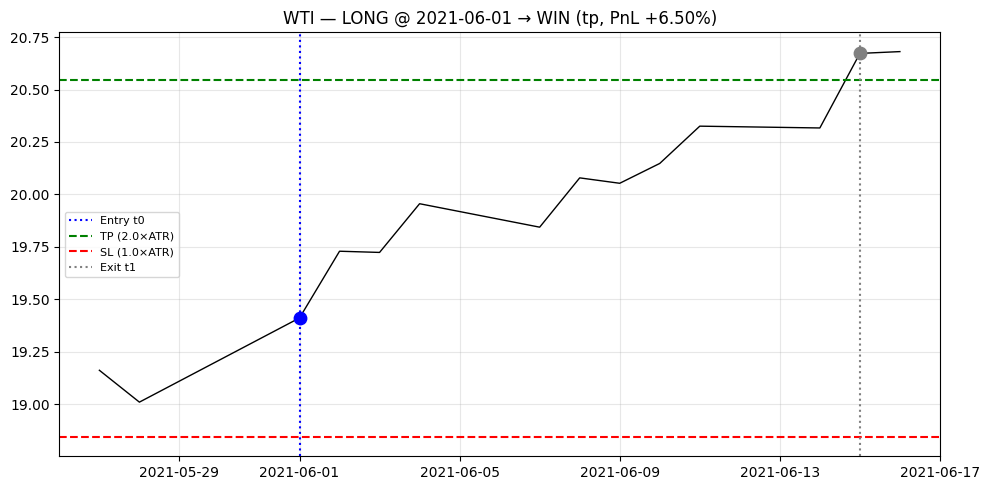

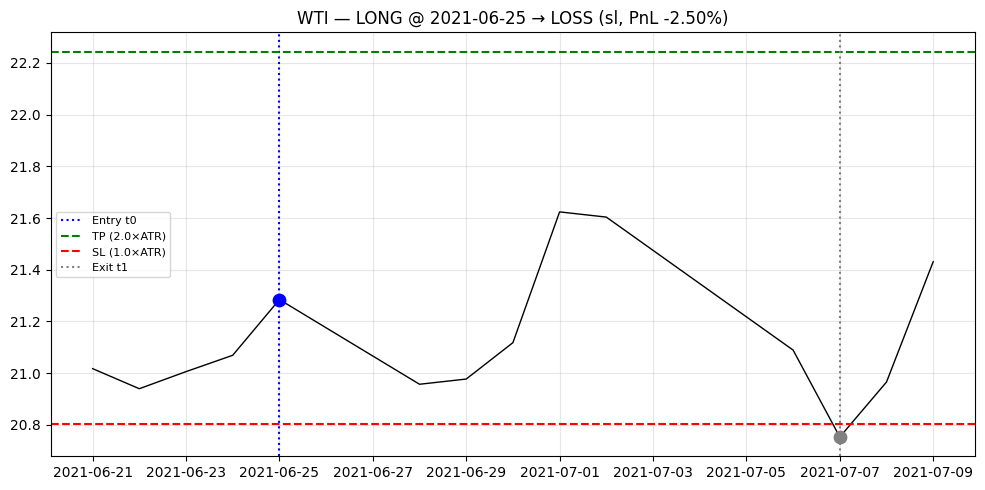

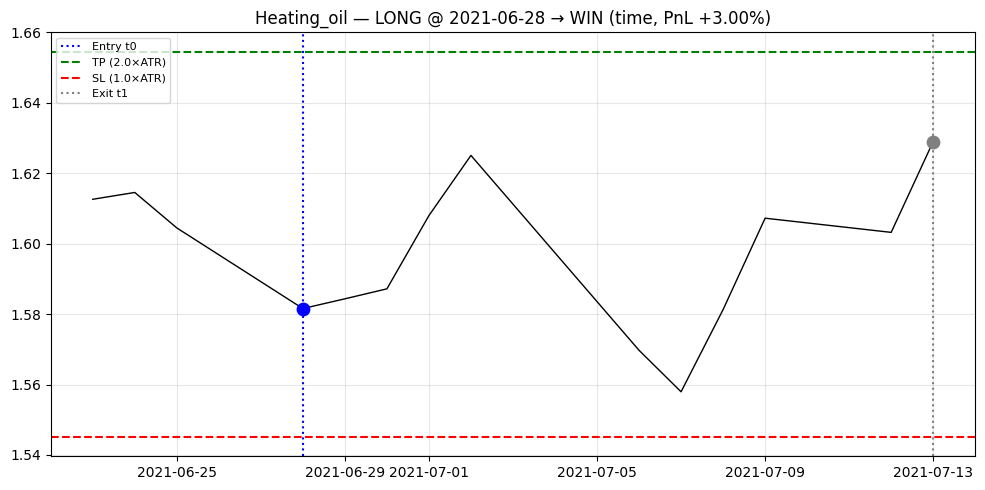

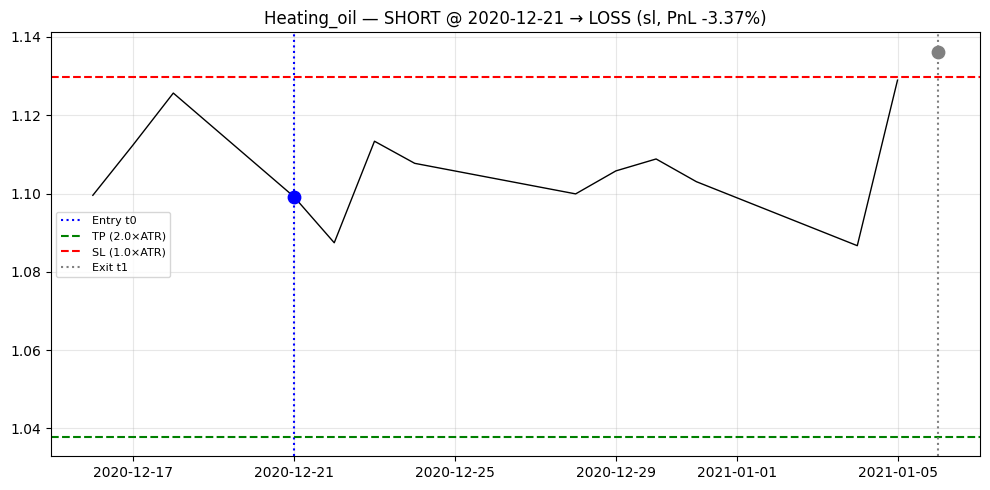

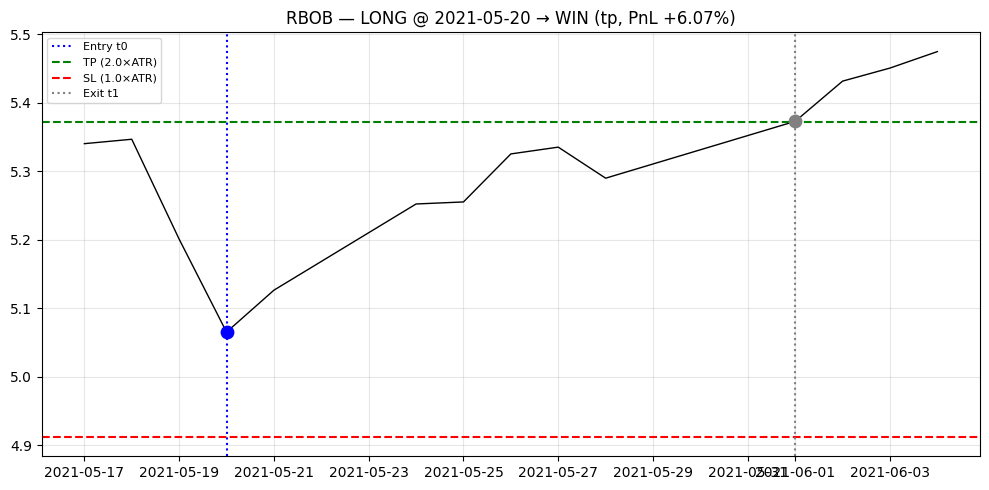

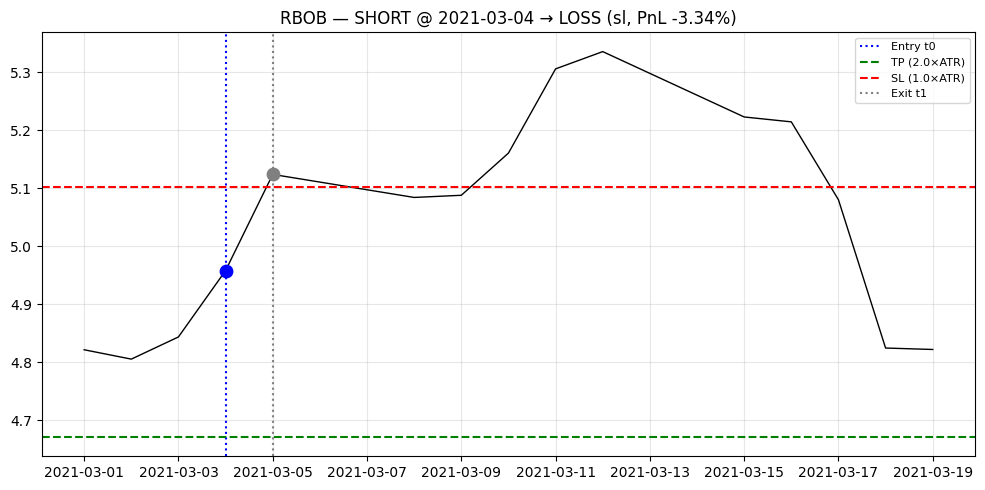

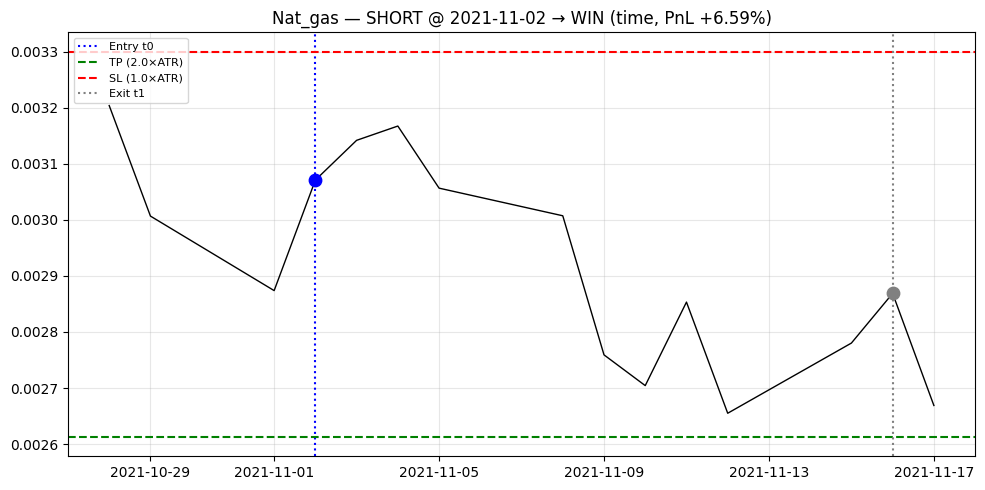

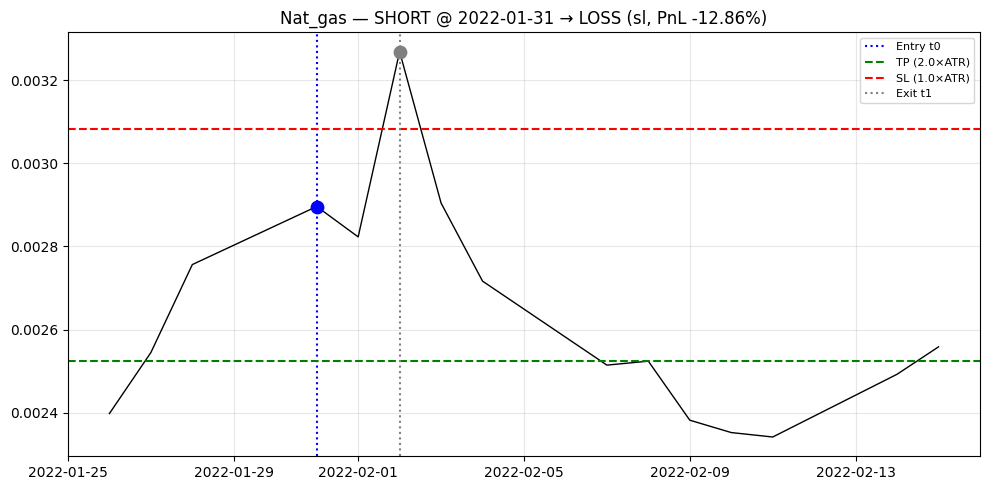

In [405]:
# ─────────────────────────────────────────────────────────────────
# VISUALISATION DE QUELQUES EXEMPLES DE TRADES LABÉLISÉS
# ─────────────────────────────────────────────────────────────────

def plot_trade_example(name, idx_t0, commo, labels_dict, 
                       horizon=10, tp_mult=2.0, sl_mult=1.0):
    """Plot un trade individuel avec ses barrières TP/SL/temps."""
    df = commo[name]
    labels = labels_dict[name]
    
    if idx_t0 not in labels.index:
        print(f"{idx_t0} pas dans les labels de {name}")
        return
    
    row = labels.loc[idx_t0]
    sig = row['signal']
    t1 = row['t1']
    
    entry_price = df.at[idx_t0, 'close']
    vol_t = df.at[idx_t0, 'atr_14']
    tp_level = entry_price + sig * tp_mult * vol_t
    sl_level = entry_price - sig * sl_mult * vol_t
    
    # Plot la fenêtre autour du trade
    window_start = idx_t0 - pd.Timedelta(days=5)
    window_end   = idx_t0 + pd.Timedelta(days=horizon+5)
    prices = df.loc[window_start:window_end, 'close']
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(prices.index, prices.values, 'k-', linewidth=1)
    
    # Marquer entry
    ax.axvline(idx_t0, color='blue', linestyle=':', label='Entry t0')
    ax.scatter([idx_t0], [entry_price], color='blue', s=80, zorder=5)
    
    # Barrières TP et SL
    ax.axhline(tp_level, color='green', linestyle='--', 
               label=f'TP ({tp_mult}×ATR)')
    ax.axhline(sl_level, color='red', linestyle='--', 
               label=f'SL ({sl_mult}×ATR)')
    
    # Barrière temporelle
    time_barrier = idx_t0 + pd.Timedelta(days=horizon * 1.4)  # approximation
    ax.axvline(t1, color='gray', linestyle=':', label=f'Exit t1')
    ax.scatter([t1], [df.at[t1, 'close']], color='gray', s=80, zorder=5)
    
    direction = "LONG" if sig == 1 else "SHORT"
    label_txt = "WIN" if row['label'] == 1 else "LOSS"
    barrier = row['barrier_touched']
    pnl = row['pnl_pct'] * 100
    
    ax.set_title(f"{name} — {direction} @ {idx_t0.date()} → {label_txt} "
                 f"({barrier}, PnL {pnl:+.2f}%)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Plot 2 exemples par commodity (un win, un loss)
for name, labels in labels_dict.items():
    if len(labels) == 0:
        continue
    wins = labels[labels['label'] == 1]
    losses = labels[labels['label'] == 0]
    if len(wins) > 0:
        plot_trade_example(name, wins.index[len(wins)//2], commo, labels_dict,
                           HORIZON, TP_MULT, SL_MULT)
    if len(losses) > 0:
        plot_trade_example(name, losses.index[len(losses)//2], commo, labels_dict,
                           HORIZON, TP_MULT, SL_MULT)

## Discussion et limitations du labeling

### Observations sur les distributions

À lire après avoir lancé l'analyse :

- **WTI** : avec ~420 trades labélisés, distribution suffisamment équilibrée pour entraîner un metamodel.
- **Heating Oil** : seulement ~63 trades. **Insuffisant** pour un metamodel robuste — limite attendue à mentionner dans l'évaluation.
- **RBOB** : signal toujours actif → 628 trades labélisés, dataset le plus riche.
- **Nat Gas** : ~124 trades, intermédiaire.

### Trade-off des paramètres

Notre choix `(horizon=10, tp_mult=2, sl_mult=1)` correspond à un **risk/reward de 2:1**, agressif mais cohérent avec la philosophie meta-labeling : on cherche à filtrer les trades où le signal primaire a peu de chances de matérialiser un profit significatif.

**Alternatives envisagées et rejetées :**
- `horizon=5` : trop court, beaucoup de barrières temporelles, perte d'info
- `horizon=20` : labels deviennent peu corrélés au signal primaire (le marché change)
- `tp_mult=sl_mult` : symétrique, mais ne reflète pas l'asymétrie naturelle d'une stratégie systematic

### Risque de leakage temporel

La date de sortie `t1` peut chevaucher l'entrée d'un trade suivant. C'est attendu et géré en **partie 3** via la **Purged K-Fold Cross-Validation** (López de Prado), qui retire les exemples d'entraînement chevauchant la fenêtre de test.

### Limitations connues

1. **Pas de slippage ni de frais** : le PnL réalisé suppose un fill parfait au close.
2. **Volatilité statique** : ATR à `t0` est utilisé pour fixer TP/SL ; on n'ajuste pas si la vol explose pendant le trade.
3. **Ordre TP/SL le même jour** : si une bougie traverse TP et SL le même jour, on labélise selon le close (au lieu d'utiliser high/low intraday). C'est une approximation conservatrice.